In [1]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from python_tsp.distances import euclidean_distance_matrix
from python_tsp.heuristics import solve_tsp_local_search
from scipy.interpolate import RegularGridInterpolator
import time
from copy import copy

import sys
sys.path.append('..')
from python import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [2]:
reencoded_10min_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t3.slp'
reencoded_10min_labels = sleap.load_file(reencoded_10min_path)
frame_cnt, x, y = reencoded_10min_labels.video.shape[:3]
print(reencoded_10min_labels)
print(reencoded_10min_labels.video.shape)

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)
(90003, 170, 174, 1)


In [3]:
from python.polygon_based_correction import *
methods = [(f'poly_{i}', eval(f'poly_{i}')) for i in range(1, 4)]

## Examine frames with/without missing points

number of frames without instances: 36276


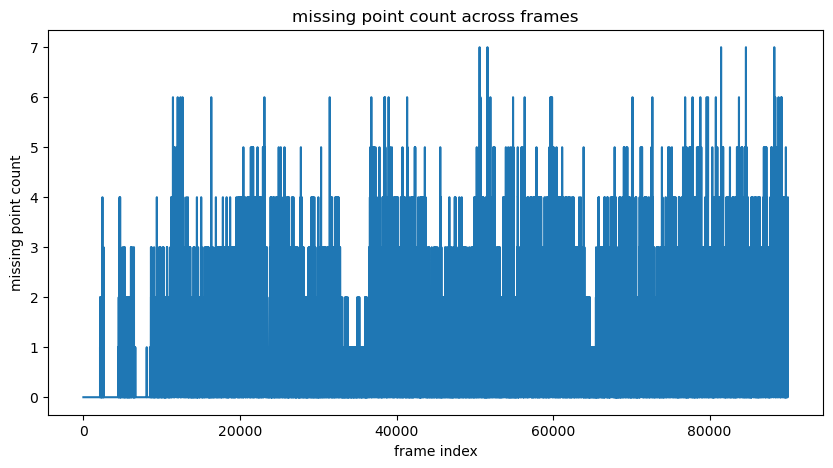

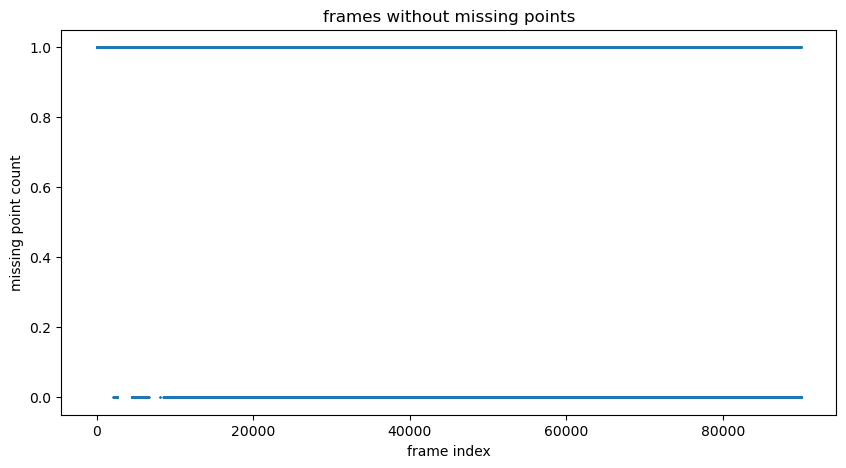

In [29]:
missing_point_cnt = np.zeros(frame_cnt - 1)
for lf in reencoded_10min_labels.labeled_frames[1:]:
    missing_point_cnt[lf.frame_idx - 1] = 17 - len(lf.instances)
print(f'number of frames without instances: {np.sum(missing_point_cnt == 0)}')
plt.figure(figsize=(10, 5))
plt.title('missing point count across frames')
plt.xlabel('frame index')
plt.ylabel('missing point count')
plt.plot(missing_point_cnt)
plt.show()

frames_without_missing_points = missing_point_cnt == 0
plt.figure(figsize=(10, 5))
plt.title('frames without missing points')
plt.xlabel('frame index')
plt.ylabel('missing point count')
# plt.plot(frames_without_missing_points)
plt.scatter(np.arange(len(frames_without_missing_points)), frames_without_missing_points, s=0.1)
plt.show()

## Save tracked points from original SLEAP dataset

In [3]:
all_tracked_points_raw = get_all_tracked_points(reencoded_10min_labels, interpolate=False, min_score=0.5)

all_tracked_points shape: (90002, 17, 2)
First non missing frame idx: 477
Missing point count: 155344
reorder_idx.shape: (17,)


In [4]:
reencoded_10min_labels_processed = dataset_with_new_points(reencoded_10min_labels, all_tracked_points_raw)
all_tracked_points_raw_0 = get_all_tracked_points(reencoded_10min_labels_processed, 
                                                  interpolate=False, min_score=0, start_idx=0)
np.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/all_tracked_points_raw_0.npy', 
            all_tracked_points_raw_0)

all_tracked_points shape: (90003, 17, 2)
First non missing frame idx: 477
Missing point count: 155345
reorder_idx.shape: (17,)


In [12]:
reencoded_10min_labels_processed.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/reencoded_10min_processed.slp')

## Get all tracked points without interpolation

In [8]:
all_tracked_points = get_all_tracked_points(reencoded_10min_labels, interpolate=False, min_score=0.5)

all_tracked_points shape: (90002, 17, 2)
First non missing frame idx: 477
Missing point count: 155344
reorder_idx.shape: (17,)


number of frames without instances: 16462


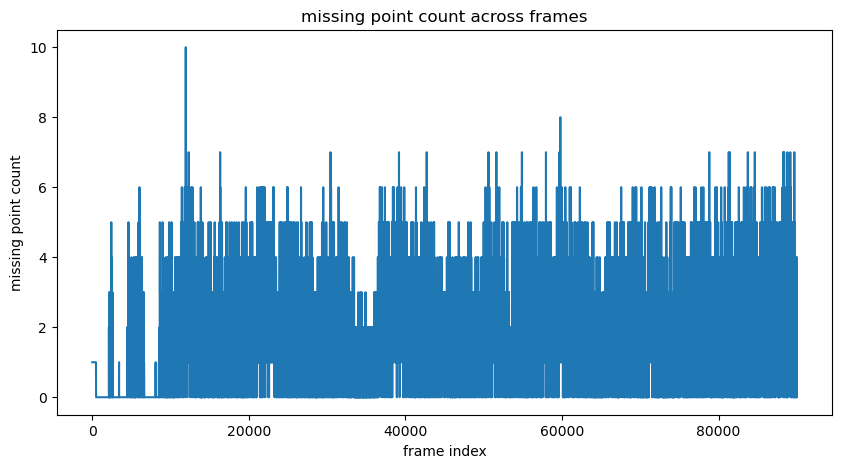

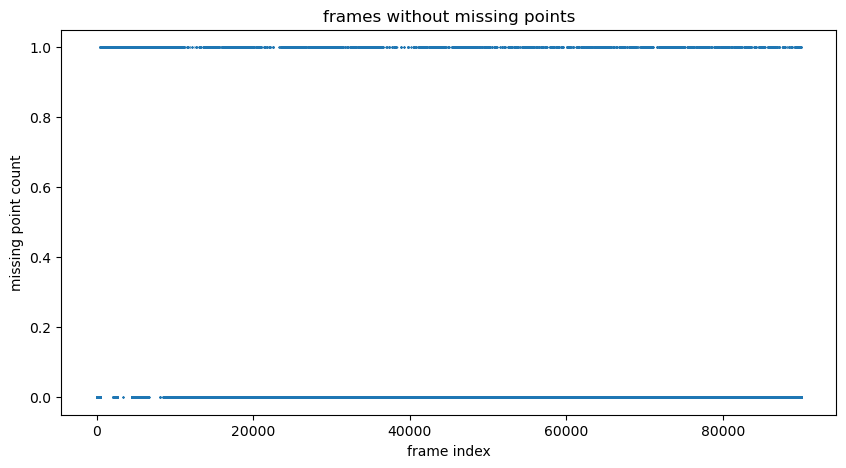

In [9]:
all_frame_missing_cnt = get_frame_missing_cnt_arr(all_tracked_points)

print(f'number of frames without instances: {np.sum(all_frame_missing_cnt == 0)}')
plt.figure(figsize=(10, 5))
plt.title('missing point count across frames')
plt.xlabel('frame index')
plt.ylabel('missing point count')
plt.plot(all_frame_missing_cnt)
plt.show()

frames_without_missing_points = all_frame_missing_cnt == 0
plt.figure(figsize=(10, 5))
plt.title('frames without missing points')
plt.xlabel('frame index')
plt.ylabel('missing point count')
# plt.plot(frames_without_missing_points)
plt.scatter(np.arange(len(frames_without_missing_points)), frames_without_missing_points, s=0.1)
plt.show()

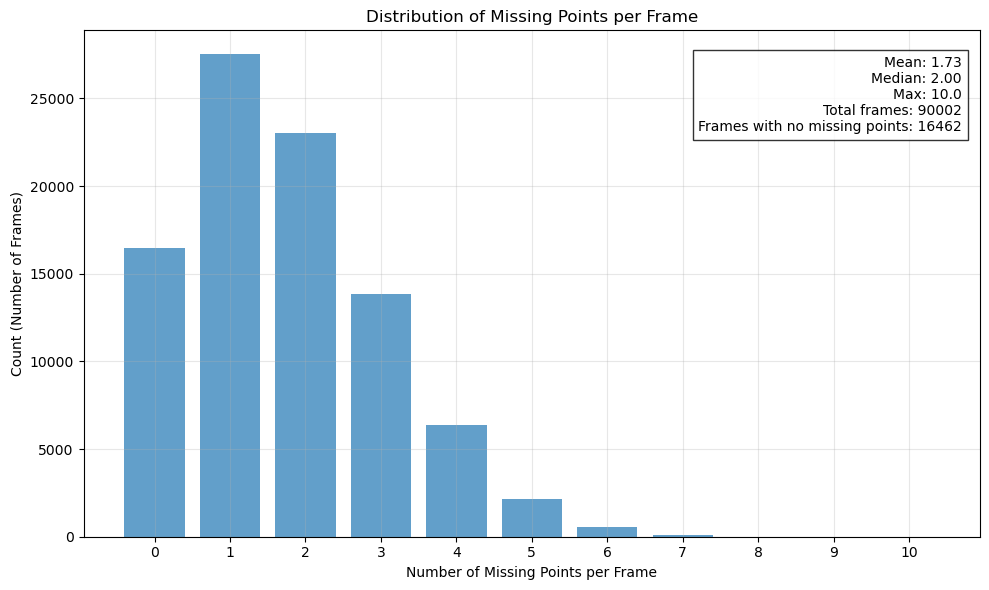


Percentage of frames with X missing points:
0 missing points: 18.3% (16462 frames)
1 missing points: 30.6% (27510 frames)
2 missing points: 25.6% (23013 frames)
3 missing points: 15.4% (13823 frames)
4 missing points: 7.1% (6397 frames)
5 missing points: 2.4% (2155 frames)
6 missing points: 0.6% (534 frames)
7 missing points: 0.1% (98 frames)
8 missing points: 0.0% (5 frames)
9 missing points: 0.0% (4 frames)
10 missing points: 0.0% (1 frames)


In [10]:
plt.figure(figsize=(10, 6))

# Create histogram
plt.hist(all_frame_missing_cnt.astype(int), bins=range(int(max(all_frame_missing_cnt)) + 2), 
         align='left', alpha=0.7, rwidth=0.8)

# Add labels and title
plt.xlabel('Number of Missing Points per Frame')
plt.ylabel('Count (Number of Frames)')
plt.title('Distribution of Missing Points per Frame')
plt.grid(True, alpha=0.3)

# Add statistics as text
stats_text = (f'Mean: {np.mean(all_frame_missing_cnt):.2f}\n'
             f'Median: {np.median(all_frame_missing_cnt):.2f}\n'
             f'Max: {np.max(all_frame_missing_cnt)}\n'
             f'Total frames: {len(all_frame_missing_cnt)}\n'
             f'Frames with no missing points: {np.sum(all_frame_missing_cnt == 0)}')

plt.text(0.98, 0.95, stats_text,
         transform=plt.gca().transAxes,
         horizontalalignment='right',
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.xticks(range(int(max(all_frame_missing_cnt)) + 1))
plt.tight_layout()
plt.show()

# Print percentage of frames with different numbers of missing points
print("\nPercentage of frames with X missing points:")
total_frames = len(all_frame_missing_cnt)
for n in range(int(max(all_frame_missing_cnt)) + 1):
    count = np.sum(all_frame_missing_cnt == n)
    percentage = 100 * count / total_frames
    print(f"{n} missing points: {percentage:.1f}% ({count} frames)")

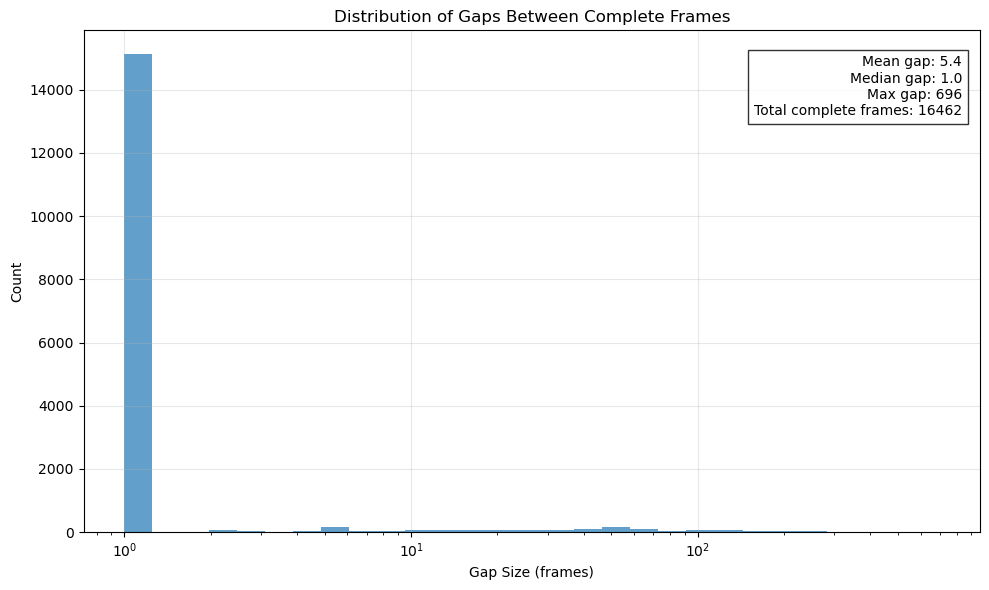


Longest gaps (frame ranges):
Gap of 696 frames between frames 22584 and 23280
Gap of 577 frames between frames 38321 and 38898
Gap of 526 frames between frames 59583 and 60109
Gap of 470 frames between frames 39269 and 39739
Gap of 463 frames between frames 71082 and 71545
Gap of 414 frames between frames 20997 and 21411
Gap of 404 frames between frames 51089 and 51493
Gap of 377 frames between frames 22100 and 22477
Gap of 374 frames between frames 87273 and 87647
Gap of 362 frames between frames 36570 and 36932
Gap of 356 frames between frames 38907 and 39263
Gap of 354 frames between frames 57562 and 57916
Gap of 354 frames between frames 39760 and 40114
Gap of 345 frames between frames 88849 and 89194
Gap of 345 frames between frames 12148 and 12493
Gap of 344 frames between frames 85367 and 85711
Gap of 326 frames between frames 87915 and 88241
Gap of 324 frames between frames 40147 and 40471
Gap of 310 frames between frames 83603 and 83913
Gap of 307 frames between frames 59062 

In [16]:
# Find indices where frames are complete (no missing points)
complete_frame_indices = np.where(frames_without_missing_points == 1)[0]

# Calculate gaps between consecutive complete frames
gaps = np.diff(complete_frame_indices)

# Plot histogram of gaps with log scale
plt.figure(figsize=(10, 6))
plt.hist(gaps, bins=np.logspace(np.log10(1), np.log10(max(gaps)), 30), alpha=0.7)
plt.xscale('log')
plt.xlabel('Gap Size (frames)')
plt.ylabel('Count')
plt.title('Distribution of Gaps Between Complete Frames')
plt.grid(True, alpha=0.3)

# Add statistics as text
plt.text(0.98, 0.95, 
         f'Mean gap: {np.mean(gaps):.1f}\n'
         f'Median gap: {np.median(gaps):.1f}\n'
         f'Max gap: {np.max(gaps)}\n'
         f'Total complete frames: {len(complete_frame_indices)}',
         transform=plt.gca().transAxes,
         horizontalalignment='right',
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print longest gaps
print("\nLongest gaps (frame ranges):")
largest_gaps = np.argsort(gaps)[-20:]  # Get indices of 5 largest gaps
for idx in reversed(largest_gaps):
    start_frame = complete_frame_indices[idx]
    end_frame = complete_frame_indices[idx + 1]
    print(f"Gap of {gaps[idx]} frames between frames {start_frame} and {end_frame}")

## Iterative correction

In [5]:
from scipy.interpolate import make_interp_spline

def interpolate_missing_points(points_to_correct):

    frame_cnt, point_cnt, _ = points_to_correct.shape
    interpolated_points = points_to_correct.copy()
    
    # Interpolate each point separately
    interpolated_cnt = 0
    for pt in range(point_cnt):
        # Get x and y coordinates for this point across all frames
        x = points_to_correct[:, pt, 0]
        y = points_to_correct[:, pt, 1]
        
        # Find frames where point is missing
        missing_mask = (x == 0) & (y == 0)
        valid_x = x[~missing_mask]
        valid_y = y[~missing_mask]
        
        valid_frames = np.where(~missing_mask)[0]
        if len(valid_frames) < 2:  # Need at least 2 points to interpolate
            print(f'not enough valid frames for point {pt}')
            continue
        interpolated_cnt += len(x) - len(valid_x)
        x_interpolator = make_interp_spline(valid_frames, valid_x, k=1)
        y_interpolator = make_interp_spline(valid_frames, valid_y, k=1)
        interpolated_points[:, pt, 0] = x_interpolator(np.arange(frame_cnt))
        interpolated_points[:, pt, 1] = y_interpolator(np.arange(frame_cnt))

    print(f'interpolated_cnt: {interpolated_cnt}')
    return interpolated_points

In [6]:
test_arr = np.array([[[0, 0]], 
                     [[0, 0]],
                     [[0, 0]],
                     [[4, 4]],
                     [[0, 0]],
                     [[6, 6]]])
interpolate_missing_points(test_arr)

interpolated_cnt: 4


array([[[1, 1]],

       [[2, 2]],

       [[3, 3]],

       [[4, 4]],

       [[5, 5]],

       [[6, 6]]])

In [15]:
np.sum(test_arr[0], axis=0)

array([0, 0])

In [10]:
all_frame_missing_cnt = get_frame_missing_cnt_arr(all_tracked_points)
all_frame_missing_cnt.shape
# np.where(all_frame_missing_cnt <= 2)[0].shape

(90002,)

In [26]:
all_frame_missing_cnt = get_frame_missing_cnt_arr(all_tracked_points)
max_missing_point_cnt = int(np.max(all_frame_missing_cnt))
print(f"Max missing point count: {max_missing_point_cnt}")
all_points_corrected = all_tracked_points.copy()
prev_correct_cnt = 0
for missing_point_cnt in range(max_missing_point_cnt + 1):
    print(f"Missing point count: {missing_point_cnt}")
    frames_to_correct = np.where(all_frame_missing_cnt <= missing_point_cnt)[0]
    if len(frames_to_correct) == prev_correct_cnt:
        continue
    curr_correct_cnt = np.sum(all_frame_missing_cnt[frames_to_correct])
    print(f'Number of (new) missing points: {curr_correct_cnt - prev_correct_cnt}')
    prev_correct_cnt = curr_correct_cnt
    points_to_correct = all_points_corrected[frames_to_correct, :, :]
    t1 = time.time()
    if missing_point_cnt > 0:
        points_to_correct = interpolate_missing_points(points_to_correct)
    t2 = time.time()
    print(f"Time taken to interpolate: {(t2 - t1):.2f} seconds")
    points_corrected = polygon_correction_with_points(points_to_correct, poly_3)
    all_points_corrected[frames_to_correct, :, :] = points_corrected
    t3 = time.time()
    print(f"Time taken: {(t3 - t2):.2f} seconds")

Max missing point count: 10
Missing point count: 0
Number of (new) missing points: 0
Number of frames to correct: 16462
Time taken to interpolate: 0.00 seconds
Time taken: 38.64 seconds
Missing point count: 1
Number of (new) missing points: -16461
Number of frames to correct: 43972
interpolated_cnt: 27510
Time taken to interpolate: 0.05 seconds
Time taken: 112.87 seconds
Missing point count: 2
Number of (new) missing points: -43970
Number of frames to correct: 66985
interpolated_cnt: 46026
Time taken to interpolate: 0.09 seconds
Time taken: 181.13 seconds
Missing point count: 3
Number of (new) missing points: -66982
Number of frames to correct: 80808
interpolated_cnt: 41469
Time taken to interpolate: 0.11 seconds
Time taken: 224.73 seconds
Missing point count: 4
Number of (new) missing points: -80804
Number of frames to correct: 87205
interpolated_cnt: 25588
Time taken to interpolate: 0.12 seconds
Time taken: 248.39 seconds
Missing point count: 5
Number of (new) missing points: -87200


In [27]:
all_points_corrected.shape

(90002, 17, 2)

In [31]:
all_points_corrected

array([[[ 30.20637512,  68.29290771],
        [ 40.36355972,  42.15752029],
        [ 58.61303711,  36.54332733],
        ...,
        [ 48.47677612, 126.76023102],
        [ 40.52921295, 106.17032623],
        [ 34.46563339,  88.38848114]],

       [[136.31373596,  72.63348389],
        [130.18322754,  56.75316238],
        [118.29833221,  40.2314682 ],
        ...,
        [112.39685059, 126.47240448],
        [130.29524231, 116.73516083],
        [140.12059021,  92.29502106]],

       [[136.31385803,  72.63357544],
        [130.18322754,  56.75316238],
        [118.29833221,  40.2314682 ],
        ...,
        [112.39678955, 126.47237396],
        [130.29522705, 116.73526764],
        [140.11950684,  92.29449463]],

       ...,

       [[ 54.40070724,  74.54781342],
        [ 64.6723938 ,  68.35630798],
        [ 68.20168304,  66.29672241],
        ...,
        [ 74.31967926, 104.4425354 ],
        [ 66.11363983,  92.4463501 ],
        [ 58.80510712,  90.26795197]],

       [[ 94.44

In [28]:
np.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/all_points_corrected_10min.npy', all_points_corrected)

In [3]:
all_points_corrected = np.load('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/all_points_corrected_10min.npy')

In [33]:
all_frame_missing_cnt = get_frame_missing_cnt_arr(all_points_corrected)
print(f'number of frames with missing instances: {np.sum(all_frame_missing_cnt != 0)}')

number of frames with missing instances: 0


## Correct & interpolate at the same time

In [22]:
def nn_align(curr_frame_pts, prev_frame_pts):
    pt_cnt = curr_frame_pts.shape[0]
    id_mapping = np.full(pt_cnt, -1)
    for curr_pt_idx, curr_pt in enumerate(curr_frame_pts):
        if np.sum(curr_pt) == 0:
            continue
        dists = np.sum((prev_frame_pts - curr_pt) ** 2, axis=1)
        nn_indices = np.argsort(dists)
        for nn_idx in nn_indices:
            if nn_idx not in id_mapping:
                id_mapping[curr_pt_idx] = nn_idx
                break
    id_mapping = np.where(id_mapping != -1, id_mapping, np.arange(pt_cnt))
    return curr_frame_pts[id_mapping]

In [23]:
all_tracked_points_copy = all_tracked_points.copy()
for frame_idx in range(2, frame_cnt - 1):
    if all_frame_missing_cnt[frame_idx] > 0:
        continue
    all_tracked_points_copy[frame_idx] = nn_align(all_tracked_points_copy[frame_idx], all_tracked_points_copy[frame_idx - 1])

In [28]:
amfc = get_frame_missing_cnt_arr(all_tracked_points_copy)
print(np.sum(amfc), 90002 * 17)
print(amfc.shape)

155344.0 1530034
(90002,)


In [29]:
for i in range(17):
    missing_cnt = np.sum(all_tracked_points_copy[:, i].sum(axis=1) == 0)
    print(f'point {i} missing cnt: {missing_cnt}')

point 0 missing cnt: 9288
point 1 missing cnt: 8671
point 2 missing cnt: 9840
point 3 missing cnt: 8945
point 4 missing cnt: 8900
point 5 missing cnt: 9150
point 6 missing cnt: 8825
point 7 missing cnt: 8627
point 8 missing cnt: 10871
point 9 missing cnt: 9565
point 10 missing cnt: 7831
point 11 missing cnt: 8475
point 12 missing cnt: 11465
point 13 missing cnt: 8354
point 14 missing cnt: 9301
point 15 missing cnt: 9493
point 16 missing cnt: 7743


In [30]:
def nn_interpolate(all_tracked_points):
    frame_cnt, pt_cnt, _ = all_tracked_points.shape
    interpolated_points = all_tracked_points.copy()
    for pt in range(pt_cnt):
        for frame_idx in range(frame_cnt):
            if np.sum(interpolated_points[frame_idx, pt]) == 0:
                prev_frame_idx = get_prev_frame_idx(interpolated_points, frame_idx, pt)
                next_frame_idx = get_next_frame_idx(interpolated_points, frame_idx, pt)
                if next_frame_idx == frame_idx:
                    next_frame_idx = prev_frame_idx
                prev_pt = interpolated_points[prev_frame_idx, pt]
                next_pt = interpolated_points[next_frame_idx, pt]
                interpolated_points[frame_idx, pt] = (prev_pt + next_pt) / 2
    return interpolated_points

In [31]:
nn_interpolated_points = nn_interpolate(all_tracked_points_copy)

In [32]:
retrain_10min_labels = dataset_with_new_points(reencoded_10min_labels, nn_interpolated_points)
retrain_10min_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/retrain_10min_v2.slp'
retrain_10min_labels.save(retrain_10min_labels_path)

## Generate animation for new correction results

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/iterative_correction_10min.mp4
Animation saved to /home/mingxiao/Desktop/animation/iterative_correction_10min.mp4


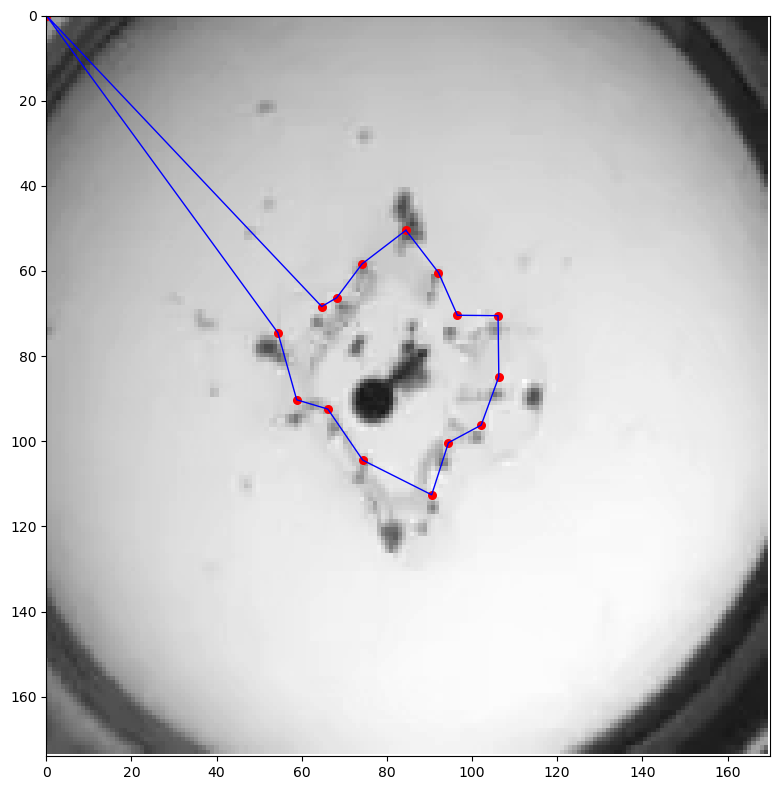

In [21]:
corrected_animation_path = '/home/mingxiao/Desktop/animation/iterative_correction_10min.mp4'
frame_cnt, x, y = reencoded_10min_labels.video.shape[:3]
get_animation_from_tracked_points(all_points_corrected, x, y, 
                                  output_path=corrected_animation_path, 
                                  bg_video=reencoded_10min_labels.video,
                                  bg_video_start_idx=0)

## Construct a new label with interpolated & corrected points

In [37]:
print(len(reencoded_10min_labels.labeled_frames[1].instances))
print(len(reencoded_10min_labels.labeled_frames))
print(reencoded_10min_labels.skeletons[0])
print(reencoded_10min_labels.labeled_frames[1].instances[0])
print(reencoded_10min_labels.labeled_frames[1].instances[0].track)
print(reencoded_10min_labels.video)
print(reencoded_10min_labels.tracks)

17
90003
Skeleton(description=None, nodes=[tb1_node], edges=[], symmetries=[])
PredictedInstance(video=Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/c1_high_res_10min_track_reencoded.mp4, shape=(90003, 170, 174, 1), backend=MediaVideo), frame_idx=1, points=[tb1_node: (94.4, 34.7, 1.00)], score=0.93, track=Track(spawned_on=0, name='track_0'), tracking_score=-0.00)
Track(spawned_on=0, name='track_0')
Video(filename=/home/mingxiao/Desktop/jellyfish/video/video_1_clips/c1_high_res_10min_track_reencoded.mp4, shape=(90003, 170, 174, 1), backend=MediaVideo)
[Track(spawned_on=0, name='track_0'), Track(spawned_on=0, name='track_1'), Track(spawned_on=0, name='track_10'), Track(spawned_on=0, name='track_11'), Track(spawned_on=0, name='track_12'), Track(spawned_on=0, name='track_13'), Track(spawned_on=0, name='track_14'), Track(spawned_on=0, name='track_15'), Track(spawned_on=0, name='track_16'), Track(spawned_on=0, name='track_17'), Track(spawned_on=0, name='track_2'), Track

In [7]:
sleap.instance.Track(spawned_on=0, name='tb1')

Track(spawned_on=0, name='tb1')

In [8]:
reencoded_10min_labels.labeled_frames[1].instances[0].points[0]

PredictedPoint(x=94.42496490478516, y=34.66992950439453, visible=True, complete=False, score=0.9958362579345703)

In [36]:
corrected_label = dataset_with_new_points(reencoded_10min_labels, all_points_corrected)

In [37]:
print(corrected_label)
corrected_label.save('/home/mingxiao/Desktop/jellyfish/video/video_1_clips/corrected_10min.slp')

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=17)


In [14]:
all_tracked_points = get_all_tracked_points(reencoded_10min_labels, interpolate=True, min_score=0.5)
retrain_10min_labels = dataset_with_new_points(reencoded_10min_labels, all_tracked_points)
retrain_10min_labels_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/retrain_10min.slp'
retrain_10min_labels.save(retrain_10min_labels_path)

all_tracked_points shape: (90002, 17, 2)
First non missing frame idx: 1
Missing point count: 7
reorder_idx.shape: (17,)


## Examine the ratio between radial vs tangential velocities for non-missing points

In [17]:
all_tracked_points.shape

(90002, 17, 2)

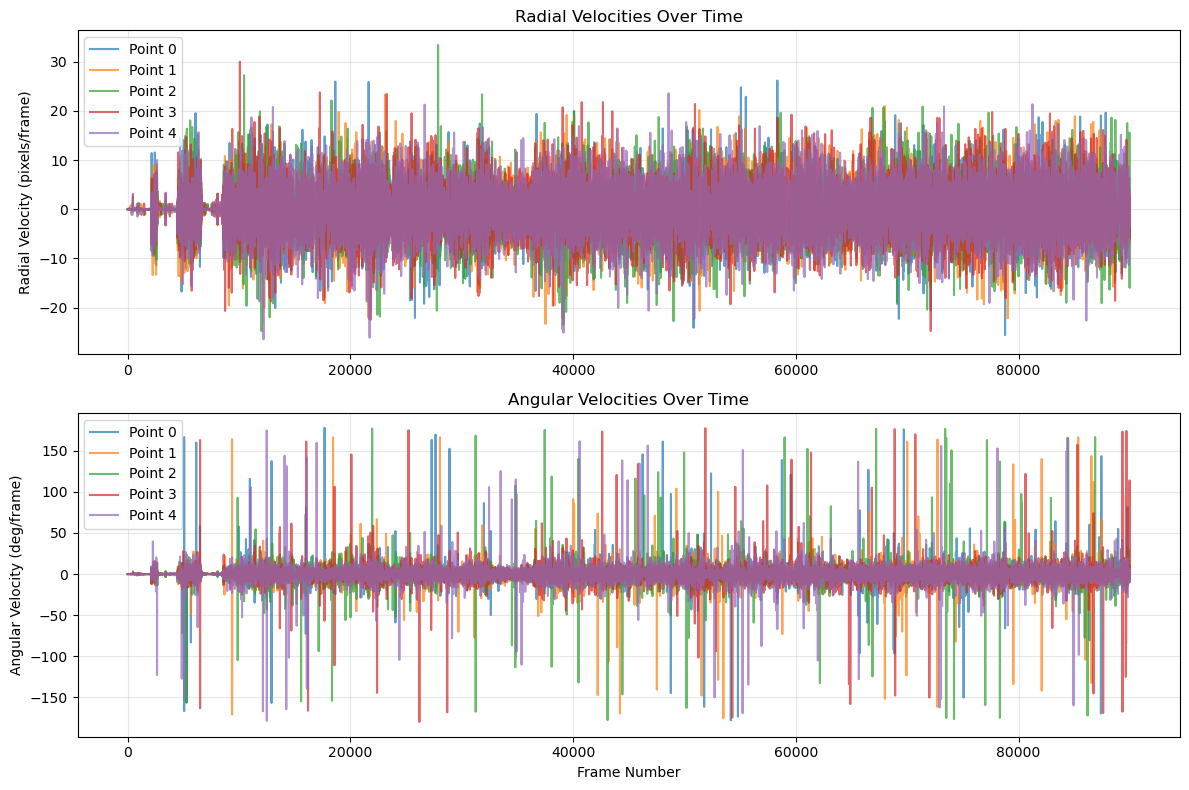

In [22]:
def calculate_velocities(all_tracked_points):
    """
    Calculate radial and angular velocities for each point
    
    Args:
        all_tracked_points: array of shape (frame_cnt, pt_cnt, 2)
        
    Returns:
        radial_velocities: array of shape (frame_cnt, pt_cnt)
        angular_velocities: array of shape (frame_cnt, pt_cnt)
    """
    frame_cnt, pt_cnt, _ = all_tracked_points.shape
    
    # Initialize velocity arrays
    radial_velocities = np.zeros((frame_cnt, pt_cnt))
    angular_velocities = np.zeros((frame_cnt, pt_cnt))
    
    # Calculate center positions for each frame
    centers = np.zeros((frame_cnt, 2))
    for frame in range(frame_cnt):
        # Find non-missing points (not at origin)
        valid_mask = np.any(all_tracked_points[frame] != 0, axis=1)
        if np.any(valid_mask):
            centers[frame] = np.mean(all_tracked_points[frame][valid_mask], axis=0)
    
    # Calculate velocities for each point
    for pt in range(pt_cnt):
        prev_frame = None
        prev_r = None
        prev_theta = None
        
        for frame in range(frame_cnt):
            pos = all_tracked_points[frame, pt]
            
            # Check if point is missing
            if np.all(pos == 0):
                radial_velocities[frame, pt] = -1
                angular_velocities[frame, pt] = -1
                continue
                
            # Calculate r and theta for current frame
            r = np.sqrt(np.sum((pos - centers[frame])**2))
            theta = np.arctan2(pos[1] - centers[frame][1], 
                             pos[0] - centers[frame][0])
            
            # Calculate velocities if we have a previous frame
            if prev_frame is not None:
                time_gap = frame - prev_frame
                
                # Radial velocity
                radial_velocities[frame, pt] = (r - prev_r) / time_gap
                
                # Angular velocity - handle wrap-around
                d_theta = theta - prev_theta
                if d_theta > np.pi:
                    d_theta -= 2*np.pi
                elif d_theta < -np.pi:
                    d_theta += 2*np.pi
                angular_velocities[frame, pt] = d_theta / time_gap
            else:
                # First valid frame for this point
                radial_velocities[frame, pt] = 0
                angular_velocities[frame, pt] = 0
            
            # Update previous values
            prev_frame = frame
            prev_r = r
            prev_theta = theta
            
    return radial_velocities, angular_velocities

# Calculate velocities
radial_velocities, angular_velocities = calculate_velocities(all_tracked_points)

# Plot example velocities for a few points
plt.figure(figsize=(12, 8))

# Plot radial velocities
plt.subplot(2, 1, 1)
for pt in range(min(5, all_tracked_points.shape[1])):  # Plot first 5 points
    valid_mask = radial_velocities[:, pt] != -1
    plt.plot(np.where(valid_mask)[0], radial_velocities[valid_mask, pt], 
             label=f'Point {pt}', alpha=0.7)
plt.ylabel('Radial Velocity (pixels/frame)')
plt.title('Radial Velocities Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot angular velocities
plt.subplot(2, 1, 2)
for pt in range(min(5, all_tracked_points.shape[1])):
    valid_mask = angular_velocities[:, pt] != -1
    plt.plot(np.where(valid_mask)[0], angular_velocities[valid_mask, pt] * (180 / np.pi), 
             label=f'Point {pt}', alpha=0.7)
plt.ylabel('Angular Velocity (deg/frame)')
plt.xlabel('Frame Number')
plt.title('Angular Velocities Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/mingxiao/micromamba/envs/sleap/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in true_divide
  


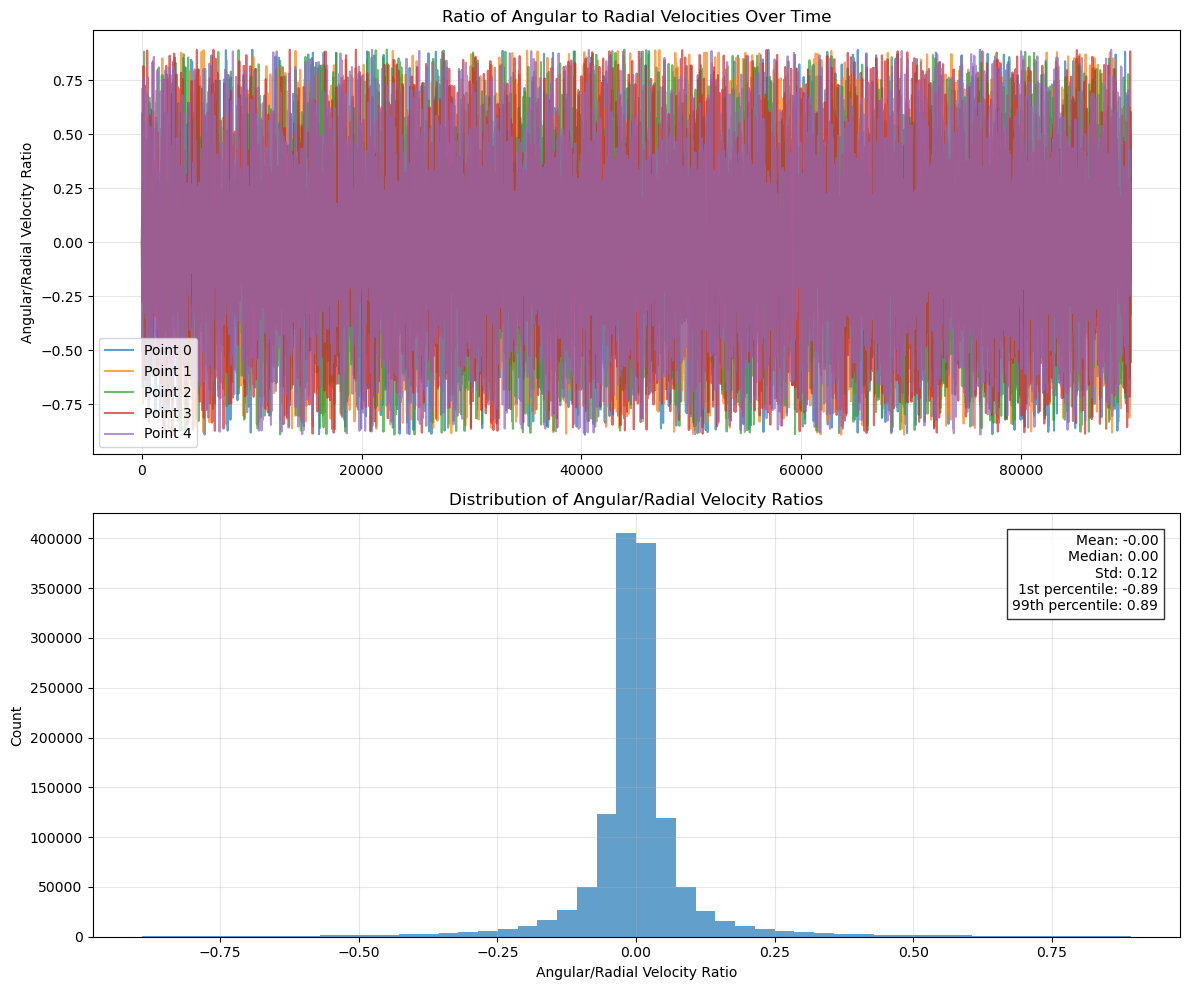


Velocity ratio statistics:
Total valid measurements: 1362901
Measurements within plotting range: 1335643
Percentage of extreme outliers: 2.0%


In [21]:
# Calculate velocity ratios
velocity_ratios = angular_velocities / radial_velocities

# Create mask for valid ratios (exclude missing points, zeros, and infinities)
valid_mask = (radial_velocities != -1) & (radial_velocities != 0) & (angular_velocities != -1)
valid_ratios = velocity_ratios[valid_mask]

# Remove extreme outliers for better visualization (using percentiles)
p1, p99 = np.percentile(valid_ratios, [1, 99])
plot_mask = (valid_ratios >= p1) & (valid_ratios <= p99)
filtered_ratios = valid_ratios[plot_mask]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Ratios over time
for pt in range(min(5, all_tracked_points.shape[1])):  # Plot first 5 points
    pt_mask = valid_mask[:, pt] & (velocity_ratios[:, pt] >= p1) & (velocity_ratios[:, pt] <= p99)
    ax1.plot(np.where(pt_mask)[0], velocity_ratios[pt_mask, pt], 
             label=f'Point {pt}', alpha=0.7)

ax1.set_ylabel('Angular/Radial Velocity Ratio')
ax1.set_title('Ratio of Angular to Radial Velocities Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of ratios
ax2.hist(filtered_ratios, bins=50, alpha=0.7)
ax2.set_xlabel('Angular/Radial Velocity Ratio')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Angular/Radial Velocity Ratios')
ax2.grid(True, alpha=0.3)

# Add statistics as text
stats_text = (f'Mean: {np.mean(filtered_ratios):.2f}\n'
             f'Median: {np.median(filtered_ratios):.2f}\n'
             f'Std: {np.std(filtered_ratios):.2f}\n'
             f'1st percentile: {p1:.2f}\n'
             f'99th percentile: {p99:.2f}')
ax2.text(0.98, 0.95, stats_text,
         transform=ax2.transAxes,
         horizontalalignment='right',
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print additional statistics
print("\nVelocity ratio statistics:")
print(f"Total valid measurements: {len(valid_ratios)}")
print(f"Measurements within plotting range: {len(filtered_ratios)}")
print(f"Percentage of extreme outliers: {100 * (1 - len(filtered_ratios)/len(valid_ratios)):.1f}%")